# 03 — Demand Normalization and Pattern Comparison

Absolute MW rises over long periods as electricity requirements grow. This notebook removes daily magnitude by dividing each hourly value by that day's mean, allowing the study to compare **when electricity is used** rather than only **how much electricity is used**.

A normalized value of `1.00` equals that day's average demand; values above/below 1 indicate hours above/below the daily average.

In [7]:
from pathlib import Path
import sys

project_root = Path.cwd().resolve()
if not (project_root / "src" / "data_preparation.py").is_file():
    project_root = project_root.parent
if not (project_root / "src" / "data_preparation.py").is_file():
    raise FileNotFoundError("Run this notebook from the project root or notebooks directory.")
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.config import PERIOD_ORDER
figures_dir = project_root / "figures"
results_dir = project_root / "results"
figures_dir.mkdir(parents=True, exist_ok=True)
results_dir.mkdir(parents=True, exist_ok=True)

from src.normalization import add_daily_normalization, normalized_hourly_profile
from src.comparison import pairwise_profile_rmse

df = pd.read_csv(project_root / "data/processed/luzon_hourly_clean.csv", parse_dates=["date", "datetime"])
df = add_daily_normalization(df)
norm = normalized_hourly_profile(df).copy()
norm["NGCP Hour No."] = norm["hour"] + 1
pivot = norm.pivot(index="NGCP Hour No.", columns="period", values="normalized_demand").reindex(columns=PERIOD_ORDER)
pivot.round(4)

period,Pre-pandemic,Pandemic,Recovery
NGCP Hour No.,,,
1,0.8883,0.9289,0.9179
2,0.8595,0.8979,0.8871
3,0.8346,0.8699,0.8604
4,0.8193,0.8489,0.8432
5,0.8252,0.8421,0.8458
6,0.8281,0.8405,0.8486
7,0.8455,0.8608,0.8620
8,0.9326,0.9344,0.9334
9,1.0278,1.0097,1.0060


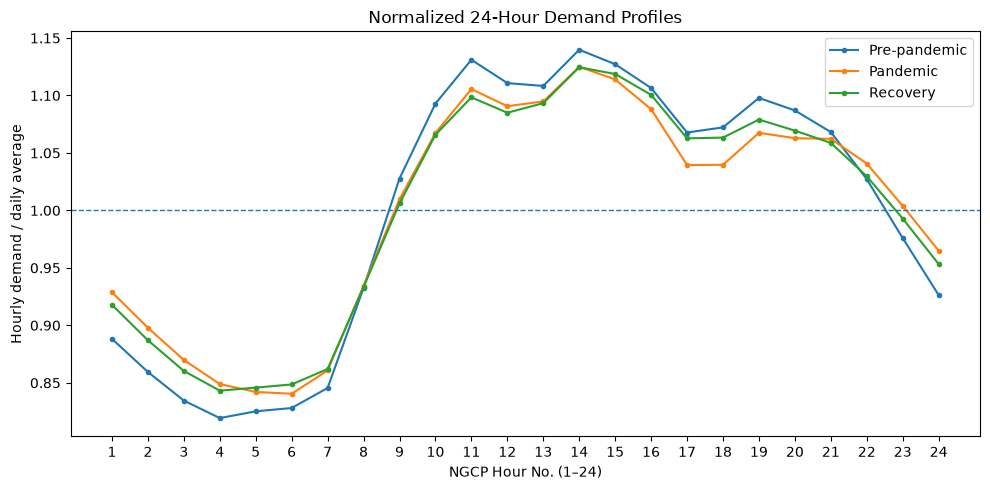

In [8]:
plt.figure(figsize=(10, 5))
for period in PERIOD_ORDER:
    plt.plot(pivot.index, pivot[period], marker="o", markersize=3, label=period)
plt.axhline(1.0, linewidth=1, linestyle="--")
plt.title("Normalized 24-Hour Demand Profiles")
plt.xlabel("NGCP Hour No. (1–24)")
plt.ylabel("Hourly demand / daily average")
plt.xticks(range(1, 25))
plt.legend()
plt.tight_layout()
plt.savefig(figures_dir / "normalized_24h_profiles.png", dpi=160)
plt.show()

In [9]:
distances = pairwise_profile_rmse(df)
distances.round(6)

,period_a,period_b,normalized_profile_rmse
0,Pre-pandemic,Pandemic,0.024776
1,Pandemic,Recovery,0.009986
2,Pre-pandemic,Recovery,0.019760


In [10]:
diffs = pd.DataFrame(index=pivot.index)
diffs["Pandemic minus Pre"] = pivot["Pandemic"] - pivot["Pre-pandemic"]
diffs["Recovery minus Pre"] = pivot["Recovery"] - pivot["Pre-pandemic"]

largest = pd.concat([
    diffs["Pandemic minus Pre"].abs().nlargest(5).rename("absolute_change").reset_index().assign(comparison="Pandemic vs Pre"),
    diffs["Recovery minus Pre"].abs().nlargest(5).rename("absolute_change").reset_index().assign(comparison="Recovery vs Pre"),
], ignore_index=True)
largest[["comparison", "NGCP Hour No.", "absolute_change"]].round(4)

,comparison,NGCP Hour No.,absolute_change
0,Pandemic vs Pre,1,0.0406
1,Pandemic vs Pre,24,0.0386
2,Pandemic vs Pre,2,0.0385
3,Pandemic vs Pre,3,0.0353
4,Pandemic vs Pre,18,0.0326
5,Recovery vs Pre,11,0.0327
6,Recovery vs Pre,1,0.0296
7,Recovery vs Pre,2,0.0276
8,Recovery vs Pre,10,0.0271
9,Recovery vs Pre,24,0.0270


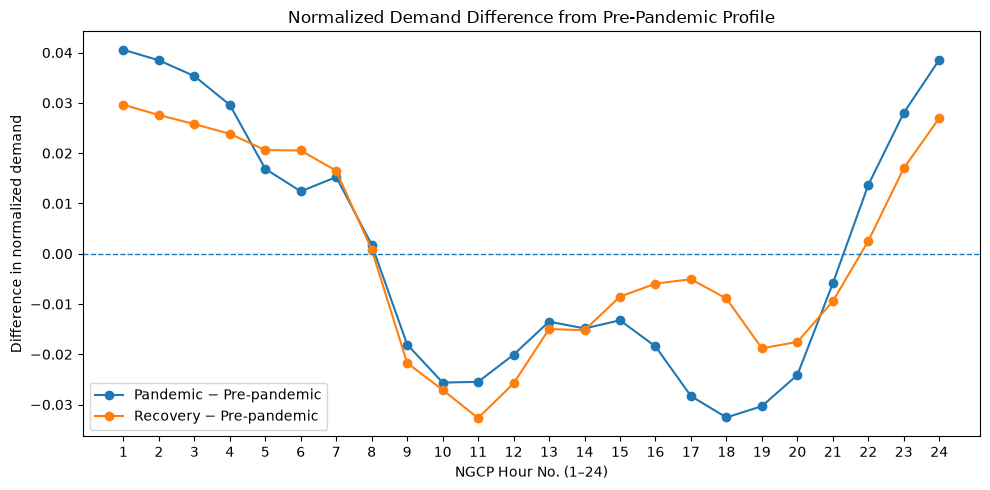

In [11]:
plt.figure(figsize=(10, 5))
plt.plot(diffs.index, diffs["Pandemic minus Pre"], marker="o", label="Pandemic − Pre-pandemic")
plt.plot(diffs.index, diffs["Recovery minus Pre"], marker="o", label="Recovery − Pre-pandemic")
plt.axhline(0, linewidth=1, linestyle="--")
plt.title("Normalized Demand Difference from Pre-Pandemic Profile")
plt.xlabel("NGCP Hour No. (1–24)")
plt.ylabel("Difference in normalized demand")
plt.xticks(range(1, 25))
plt.legend()
plt.tight_layout()
plt.savefig(figures_dir / "normalized_profile_differences.png", dpi=160)
plt.show()

In [12]:
norm.to_csv(results_dir / "normalized_hourly_profiles.csv", index=False)
distances.to_csv(results_dir / "pairwise_normalized_profile_rmse.csv", index=False)
pre_pan = distances.query("period_a == 'Pre-pandemic' and period_b == 'Pandemic'")["normalized_profile_rmse"].iloc[0]
pre_rec = distances.query("period_a == 'Pre-pandemic' and period_b == 'Recovery'")["normalized_profile_rmse"].iloc[0]
print("PATTERN INTERPRETATION")
print(f"- Pre-pandemic vs Pandemic normalized-profile RMSE: {pre_pan:.6f}")
print(f"- Pre-pandemic vs Recovery normalized-profile RMSE: {pre_rec:.6f}")
print("- Smaller RMSE means more similar 24-hour shape after controlling for each day's average demand.")
print("- The final recovery classification is made in Notebook 07 using an empirical pre-pandemic baseline tolerance.")

PATTERN INTERPRETATION
- Pre-pandemic vs Pandemic normalized-profile RMSE: 0.024776
- Pre-pandemic vs Recovery normalized-profile RMSE: 0.019760
- Smaller RMSE means more similar 24-hour shape after controlling for each day's average demand.
- The final recovery classification is made in Notebook 07 using an empirical pre-pandemic baseline tolerance.
